In [1]:
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
from clustering_statistics import tools, box_tools

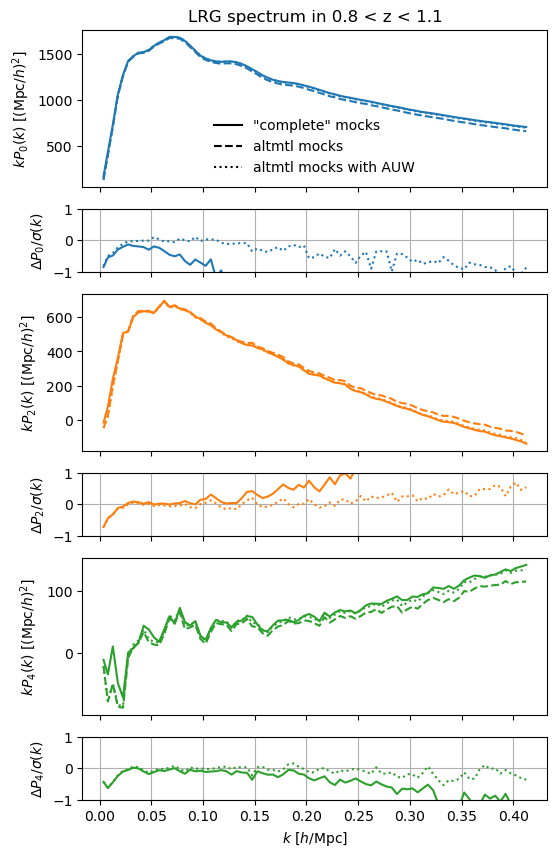

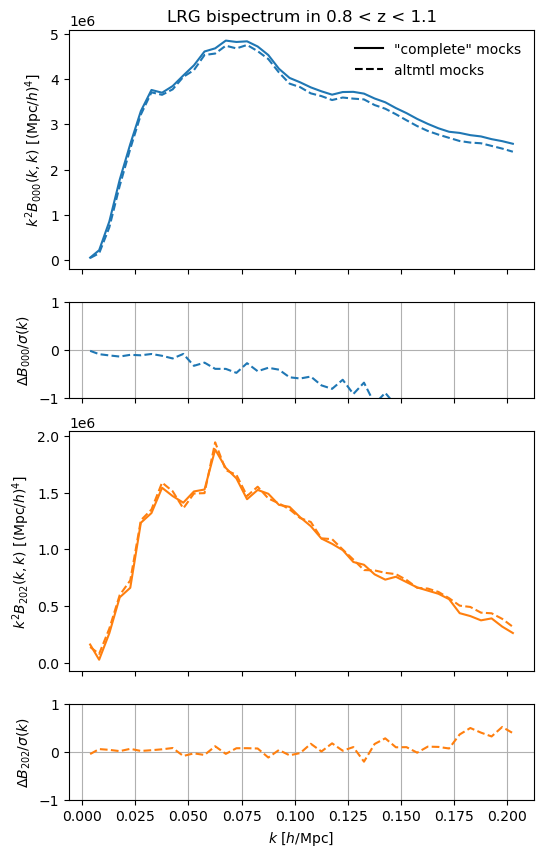

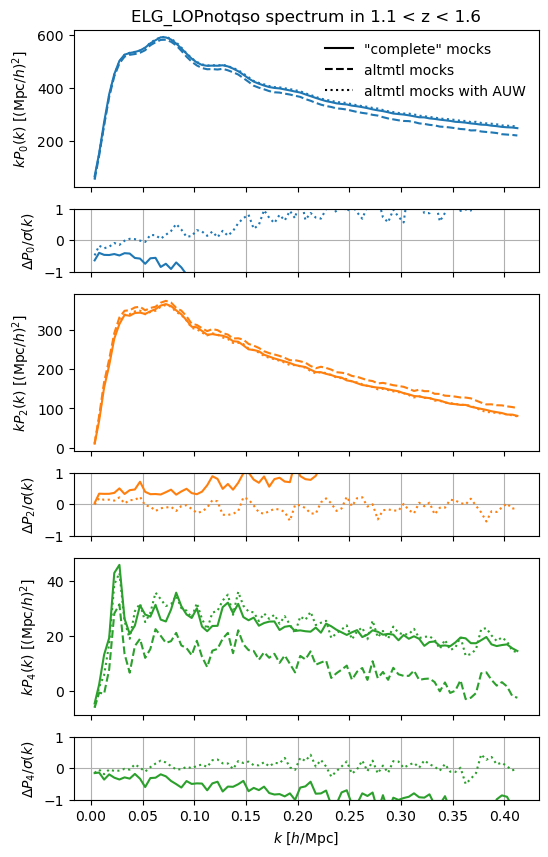

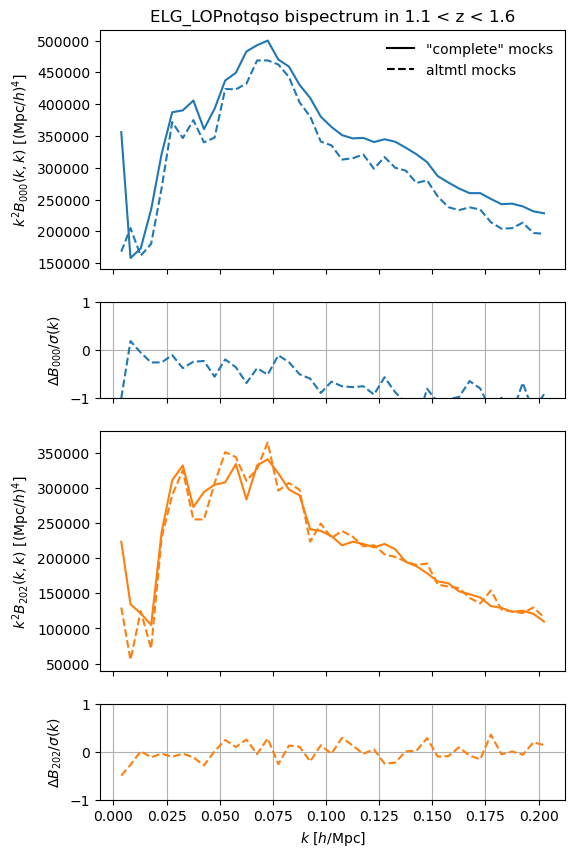

In [2]:
for tracer in ['LRG', 'ELG_LOPnotqso']:
    for zrange in tools.propose_fiducial('zranges', tracer)[-1:]:
        for kind in ['mesh2_spectrum', 'mesh3_spectrum']:
            stats_dir = tools.base_stats_dir
            project = 'full_shape/fiber_assignment_systematics'
            region = 'NGC'
            nmocks = 25
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version='abacus-hf-dr2-v2-altmtl', tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(nmocks)]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            cov = types.cov(mocks)
            cov = cov.at.observable.select(k=slice(0, None, 5 if 'mesh2' in kind else 1))
            mean = cov.observable
            if 'mesh2' in kind:
                fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version='abacus-hf-dr2-v2-altmtl', tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock, auw=True) for imock in range(nmocks)]
                mocks = [types.read(fn) for fn in fns if fn.exists()]
                mean_auw = types.mean(mocks).match(mean)
                #mean_auw = mean
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version='abacus-hf-dr2-v2-altmtl', tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', extra='complete',
                                      imock=imock) for imock in range(nmocks)]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            mean_complete = types.mean(mocks).match(mean)
            nmocks = len(mocks)  # scale error bars
            if 'mesh2' in kind:
                ells = mean.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(mean.ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
                    color = f'C{ill:d}'
                    pole = mean_complete.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='-')
                    pole = mean.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='--')
                    pole = mean_auw.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle=':')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta P_{ell:d} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    pole = mean.get(ell)
                    std = cov.at.observable.get(ell).std() # / nmocks**0.5
                    pole_complete = mean_complete.get(ell)
                    ax.plot(pole.coords('k'), (pole.value() - pole_complete.value()) / std, color=color, linestyle='-')
                    pole = mean_auw.get(ell)
                    ax.plot(pole.coords('k'), (pole.value() - pole_complete.value()) / std, color=color, linestyle=':')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='"complete" mocks')
                ax.plot([], [], color='k', linestyle='--', label='altmtl mocks')
                ax.plot([], [], color='k', linestyle=':', label='altmtl mocks with AUW')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)
                plt.show()

            elif 'mesh3' in kind:
                ells = mean.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} bispectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k^2 B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')
                    color = f'C{ill:d}'
                    pole = mean_complete.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle='-')
                    pole = mean.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle='--')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    pole = mean.get(ell)
                    std = cov.at.observable.get(ell).std() # / nmocks**0.5
                    pole_complete = mean_complete.get(ell)
                    ax.plot(k, (pole.value() - pole_complete.value()) / std, color=color, linestyle='--')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='"complete" mocks')
                ax.plot([], [], color='k', linestyle='--', label='altmtl mocks')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)
                plt.show()